# Step 4b — The Neupert lead across all 95 flares

Notebook 01 measured one flare. The X1.7 gave a clean 8-minute derivative lead,
but it had a 16-minute rise — nearly double the median. **One flare is an
anecdote.** This notebook turns it into a distribution.

The question: *across every flare in the week, how far ahead of the soft peak
does the soft derivative peak?* That number is the honest version of your
early-warning claim.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../data") if Path("../data").exists() else Path("data")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

SOFT, HARD, ACC = "#c0392b", "#e67e22", "#2c7fb8"

df = pd.read_parquet(DATA / "goes_xrs.parquet")
fl = pd.read_parquet(DATA / "flares.parquet")
for c in ["event_starttime", "event_peaktime", "event_endtime"]:
    fl[c] = pd.to_datetime(fl[c])
fl = fl.sort_values("event_starttime").reset_index(drop=True)
fl["rise_min"] = (fl["event_peaktime"] - fl["event_starttime"]).dt.total_seconds() / 60

print(f"{len(df):,} flux rows, {len(fl)} flares")

10,080 flux rows, 95 flares


## 1. Measuring one flare, carefully

Three guards matter here, and they are the difference between a real
measurement and a plausible-looking number:

**Neighbour clipping.** Flares cluster. If the window bleeds into the flare
next door, `idxmax()` may find *that* flare's peak instead. So each window is
clipped at the neighbouring events.

**Peak agreement.** After measuring, check that the peak we found is within a
few minutes of the catalogued peak. If it is not, the window is contaminated
and the flare is skipped rather than silently contributing a wrong number.

**Smoothing sensitivity.** `np.gradient` on 1-minute data is noisy, so the
derivative gets smoothed — but smoothing *shifts* the peak it is meant to
locate. We measure at two smoothing widths and compare.

In [2]:
def measure(i, smooth=3, pad_min=30, tol_min=4):
    """Return peak times for flare i, or None if the window is unreliable."""
    f = fl.loc[i]
    lo = f["event_starttime"] - pd.Timedelta(minutes=pad_min)
    hi = f["event_endtime"] + pd.Timedelta(minutes=pad_min)

    # GUARD 1: do not bleed into neighbouring flares
    if i > 0:
        lo = max(lo, fl.loc[i - 1, "event_endtime"])
    if i < len(fl) - 1:
        hi = min(hi, fl.loc[i + 1, "event_starttime"])

    w = df.loc[lo:hi]
    if len(w) < 12:
        return None

    b = w["xrsb"].interpolate()
    a = w["xrsa"].interpolate()
    if b.isna().any() or a.isna().any():
        return None

    db = pd.Series(np.gradient(b.values), index=b.index)
    db = db.rolling(smooth, center=True, min_periods=1).mean()

    b_pk, a_pk, d_pk = b.idxmax(), a.idxmax(), db.idxmax()

    # GUARD 2: does our measured peak agree with the catalogue?
    off = abs((b_pk - f["event_peaktime"]).total_seconds()) / 60
    if off > tol_min:
        return None

    return {
        "idx": i,
        "cls": f["fl_goescls"],
        "letter": f["class_letter"],
        "rise_min": f["rise_min"],
        "lead_deriv": (b_pk - d_pk).total_seconds() / 60,
        "lead_xrsa": (b_pk - a_pk).total_seconds() / 60,
    }


rows = [r for r in (measure(i) for i in fl.index) if r is not None]
res = pd.DataFrame(rows)

print(f"Measured : {len(res)} of {len(fl)} flares")
print(f"Skipped  : {len(fl) - len(res)}  (contaminated window, gaps, or peak disagreement)")

Measured : 82 of 95 flares
Skipped  : 13  (contaminated window, gaps, or peak disagreement)


## 2. The headline number

In [3]:
print("DERIVATIVE LEAD  (soft peak minus derivative peak), minutes")
print(res["lead_deriv"].describe()[["count", "mean", "50%", "min", "max"]].round(1))
print()
print("xrsa LEAD  (soft peak minus xrsa peak), minutes")
print(res["lead_xrsa"].describe()[["count", "mean", "50%", "min", "max"]].round(1))
print()
print("By class:")
print(res.groupby("letter")[["lead_deriv", "lead_xrsa", "rise_min"]].median().round(1))

DERIVATIVE LEAD  (soft peak minus derivative peak), minutes
count    82.0
mean      3.9
50%       3.0
min       1.0
max      17.0
Name: lead_deriv, dtype: float64

xrsa LEAD  (soft peak minus xrsa peak), minutes
count    82.0
mean      1.4
50%       1.0
min       0.0
max      14.0
Name: lead_xrsa, dtype: float64

By class:
        lead_deriv  lead_xrsa  rise_min
letter                                 
C              2.5        1.0       7.0
M              3.0        1.0       9.0
X              5.0        2.0      12.5


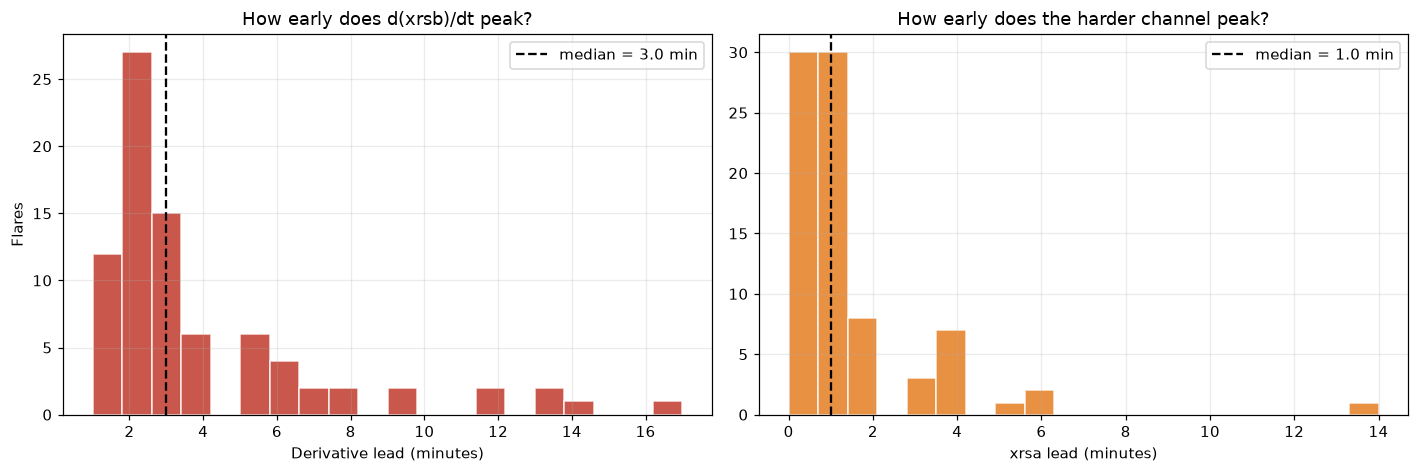

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

axes[0].hist(res["lead_deriv"], bins=20, color=SOFT, alpha=0.85, edgecolor="white")
axes[0].axvline(res["lead_deriv"].median(), color="black", ls="--",
                label=f"median = {res['lead_deriv'].median():.1f} min")
axes[0].set_xlabel("Derivative lead (minutes)")
axes[0].set_ylabel("Flares")
axes[0].set_title("How early does d(xrsb)/dt peak?")
axes[0].legend()

axes[1].hist(res["lead_xrsa"], bins=20, color=HARD, alpha=0.85, edgecolor="white")
axes[1].axvline(res["lead_xrsa"].median(), color="black", ls="--",
                label=f"median = {res['lead_xrsa'].median():.1f} min")
axes[1].set_xlabel("xrsa lead (minutes)")
axes[1].set_title("How early does the harder channel peak?")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Does the lead scale with rise time?

This is the question that decides whether your warning time is a fixed budget or
a proportion. If lead grows with rise time, then **fast flares — the dangerous,
sudden ones — give you the least warning**, which is exactly the wrong way round
for an operational system.

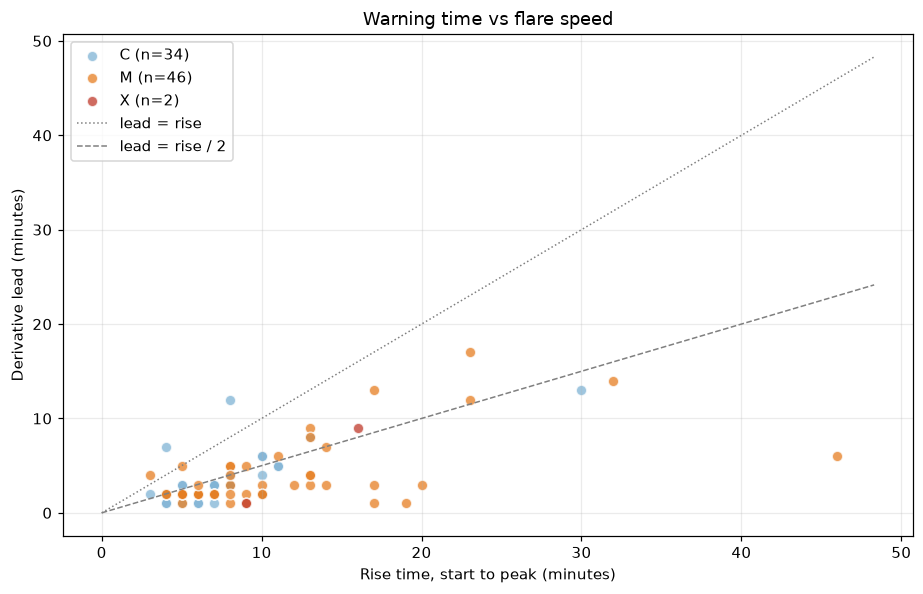

Correlation (rise time vs derivative lead): 0.59

Fast flares (rise <= 5 min): n=19, median lead = 2.0 min
Slow flares (rise >= 15 min): n=11, median lead = 9.0 min


In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
colors = {"C": "#7fb3d5", "M": HARD, "X": SOFT}
for letter, g in res.groupby("letter"):
    ax.scatter(g["rise_min"], g["lead_deriv"], s=48, alpha=0.75,
               color=colors.get(letter, "gray"), edgecolor="white",
               label=f"{letter} (n={len(g)})")

lim = res["rise_min"].max() * 1.05
ax.plot([0, lim], [0, lim], ls=":", color="gray", lw=1, label="lead = rise")
ax.plot([0, lim], [0, lim / 2], ls="--", color="gray", lw=1, label="lead = rise / 2")
ax.set_xlabel("Rise time, start to peak (minutes)")
ax.set_ylabel("Derivative lead (minutes)")
ax.set_title("Warning time vs flare speed")
ax.legend()
plt.tight_layout()
plt.show()

r = res["rise_min"].corr(res["lead_deriv"])
print(f"Correlation (rise time vs derivative lead): {r:.2f}")
print()
fast = res[res["rise_min"] <= 5]
print(f"Fast flares (rise <= 5 min): n={len(fast)}, median lead = {fast['lead_deriv'].median():.1f} min")
slow = res[res["rise_min"] >= 15]
print(f"Slow flares (rise >= 15 min): n={len(slow)}, median lead = {slow['lead_deriv'].median():.1f} min")

## 4. Is the number an artefact of smoothing?

Smoothing the derivative shifts the peak it is supposed to locate. If your
result changes a lot between smoothing widths, it is a property of your filter,
not of the Sun. Run this before quoting any figure.

In [6]:
for s in [1, 3, 5, 9]:
    rr = [r for r in (measure(i, smooth=s) for i in fl.index) if r is not None]
    rr = pd.DataFrame(rr)
    print(f"smooth={s:>2} min : n={len(rr):>3}, median lead = {rr['lead_deriv'].median():>4.1f} min")

smooth= 1 min : n= 82, median lead =  3.0 min
smooth= 3 min : n= 82, median lead =  3.0 min
smooth= 5 min : n= 82, median lead =  3.0 min
smooth= 9 min : n= 82, median lead =  5.0 min


## 5. What to take from this

Fill these in from the output above — they go straight into your report:

| Quantity | Value |
|---|---|
| Median derivative lead | ___ min |
| Median `xrsa` lead | ___ min |
| Lead for fast flares (rise ≤ 5 min) | ___ min |
| Correlation, rise time vs lead | ___ |
| Stable across smoothing widths? | yes / no |

**How to read it.** The derivative lead is the ceiling on what a *soft-X-ray-only*
system can achieve — your GOES baseline. HEL1OS should reach that ceiling
directly by observing non-thermal emission instead of inferring it from a
derivative, and with far less noise, since a measured signal beats a numerical
gradient of a noisy one.

If fast flares show a lead close to zero, say so plainly in your write-up. A
system honest about where it fails is worth more than one that reports a single
median and hopes nobody asks.